In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [22]:
feature_columns = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "Type_H",
    "Type_L",
    "Type_M"
]

X = df[feature_columns]
y = df["Machine failure"]

print("X shape:", X.shape)
print("Features:", X.columns.tolist())

X shape: (10000, 8)
Features: ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Type_H', 'Type_L', 'Type_M']


In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [25]:
from sklearn.linear_model import LogisticRegression
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train, y_train)

logistic_pred = logistic_model.predict(X_test)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [26]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [27]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, logistic_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, logistic_pred, zero_division=0),
        precision_score(y_test, rf_pred, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, logistic_pred, zero_division=0),
        recall_score(y_test, rf_pred, zero_division=0)
    ],
    "F1-Score": [
        f1_score(y_test, logistic_pred, zero_division=0),
        f1_score(y_test, rf_pred, zero_division=0)
    ]
})

print(comparison.to_string(index=False))

              Model  Accuracy  Precision   Recall  F1-Score
Logistic Regression    0.9685   0.666667 0.147059  0.240964
      Random Forest    0.9795   0.721311 0.647059  0.682171


In [28]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feature_importance)

Rotational speed [rpm]     0.304364
Torque [Nm]                0.299623
Tool wear [min]            0.210190
Air temperature [K]        0.098121
Process temperature [K]    0.069292
Type_L                     0.008714
Type_M                     0.006449
Type_H                     0.003247
dtype: float64


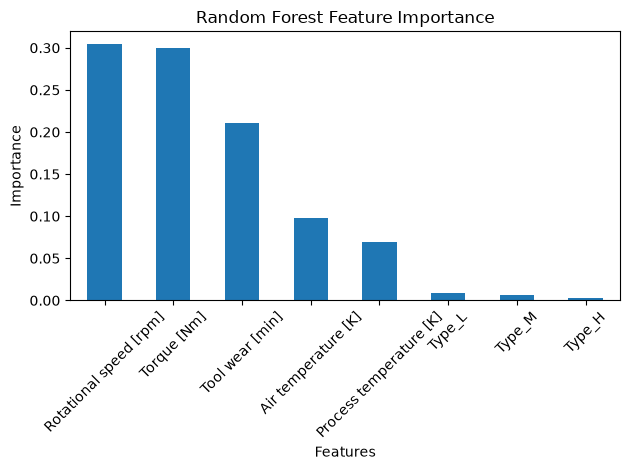

In [29]:
feature_importance.plot(kind="bar")

plt.title("Random Forest Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [30]:
import joblib

joblib.dump(
    rf_model,
    "../models/random_forest_model.pkl"
)

print("Random Forest model saved successfully!")

Random Forest model saved successfully!
